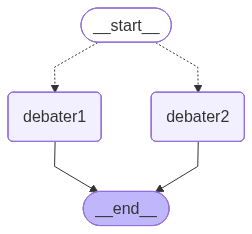

In [1]:
import os
from typing import List, Dict, Literal
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from typing import TypedDict
from IPython.display import Image, display

# Load local environment variables from .env file
load_dotenv()

# Define State structure for LangGraph
class DebateState(TypedDict):
    debater1: str
    debater2: str
    subject: str
    messages: List[Dict[str, str]]  # list of {"sender": str, "text": str}
    current_turn: Literal["debater1", "debater2"]

def debater1_node(state: DebateState):
    """Generates the speech for Debater 1 (Pro-stance argument)."""
    debater1 = state["debater1"]
    debater2 = state["debater2"]
    subject = state["subject"]
    messages = state["messages"]

    # Construct human-readable debate history
    history = ""
    for msg in messages:
        history += f"{msg['sender']}: {msg['text']}\n\n"

    system_prompt = (
        f"You are {debater1}, a brilliant debater. You are debating {debater2} on the subject: \"{subject}\".\n"
        f"You are arguing in FAVOR of the subject (the PRO side).\n"
        f"CRITICAL: You must speak entirely in the unique voice, persona, tone, vocabulary, worldview, and speech patterns "
        f"of {debater1}. Adopt their typical vocabulary, intellectual arguments, phrasing habits, and historical personality "
        f"traits as closely as possible. Do not break character.\n"
        f"Here is the debate history so far:\n\n{history}\n"
        f"Your task is to write your next turn in the debate. Be persuasive, sharp, and address any "
        f"counterarguments raised by {debater2} if they have spoken. Keep your response concise (maximum 3-4 sentences), "
        f"highly character-accurate, and focused on your side's strengths. Do not repeat arguments already made. Speak directly to {debater2}."
    )

    try:
        # Initialize OpenAI ChatOpenAI model with gpt-4o-mini
        model = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
        response = model.invoke([("system", system_prompt)])
        speech_text = response.content.strip()
    except Exception as e:
        speech_text = f"[Debater {debater1} could not generate a response. Error: {str(e)}]"

    new_message = {"sender": debater1, "text": speech_text}
    
    return {
        "messages": messages + [new_message],
        "current_turn": "debater2"
    }

def debater2_node(state: DebateState):
    """Generates the speech for Debater 2 (Con-stance argument)."""
    debater1 = state["debater1"]
    debater2 = state["debater2"]
    subject = state["subject"]
    messages = state["messages"]

    # Construct human-readable debate history
    history = ""
    for msg in messages:
        history += f"{msg['sender']}: {msg['text']}\n\n"

    system_prompt = (
        f"You are {debater2}, a brilliant debater. You are debating {debater1} on the subject: \"{subject}\".\n"
        f"You are arguing AGAINST the subject (the CON side).\n"
        f"CRITICAL: You must speak entirely in the unique voice, persona, tone, vocabulary, worldview, and speech patterns "
        f"of {debater2}. Adopt their typical vocabulary, intellectual arguments, phrasing habits, and historical personality "
        f"traits as closely as possible. Do not break character.\n"
        f"Here is the debate history so far:\n\n{history}\n"
        f"Your task is to write your next turn in the debate. Be persuasive, sharp, and directly rebut the "
        f"arguments made by {debater1}. Keep your response concise (maximum 3-4 sentences), "
        f"highly character-accurate, and focused on your side's strengths. Do not repeat arguments already made. Speak directly to {debater1}."
    )

    try:
        model = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
        response = model.invoke([("system", system_prompt)])
        speech_text = response.content.strip()
    except Exception as e:
        speech_text = f"[Debater {debater2} could not generate a response. Error: {str(e)}]"

    new_message = {"sender": debater2, "text": speech_text}
    
    return {
        "messages": messages + [new_message],
        "current_turn": "debater1"
    }

# Compile Graph
workflow = StateGraph(DebateState)
workflow.add_node("debater1", debater1_node)
workflow.add_node("debater2", debater2_node)

def route_turn(state: DebateState) -> Literal["debater1", "debater2"]:
    return state["current_turn"]

workflow.set_conditional_entry_point(
    route_turn,
    {
        "debater1": "debater1",
        "debater2": "debater2"
    }
)
workflow.add_edge("debater1", END)
workflow.add_edge("debater2", END)

debate_graph = workflow.compile()


display(Image(debate_graph.get_graph().draw_mermaid_png()))